Install Library


In [9]:
!pip install openeo
!pip install netCDF4

Autentikasi dan Pengambilan Data

In [10]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


Definisi Area dan Pengambilan Data NO₂, SO₂, O₃ dan CO dari geojson

In [11]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["NO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi);

# Simpan hasil sebagai CSV
result = s5p_no2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_no2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_no2")

0:00:00 Job 'j-26091305103044cab8dace38b14d34df': send 'start'
0:00:03 Job 'j-26091305103044cab8dace38b14d34df': queued (progress 0%)
0:00:08 Job 'j-26091305103044cab8dace38b14d34df': queued (progress 0%)
0:00:15 Job 'j-26091305103044cab8dace38b14d34df': queued (progress 0%)
0:00:23 Job 'j-26091305103044cab8dace38b14d34df': queued (progress 0%)
0:00:33 Job 'j-26091305103044cab8dace38b14d34df': queued (progress 0%)
0:00:45 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:01:01 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:01:20 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:01:45 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:02:15 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:02:52 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:03:39 Job 'j-26091305103044cab8dace38b14d34df': running (progress N/A)
0:04:38 Job 'j-26091305103044cab8dace38b14d34df': finished (progress 10

[PosixPath('output_no2/timeseries.csv'),
 PosixPath('output_no2/job-results.json')]

In [12]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_so2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_so2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_so2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_so2")

0:00:00 Job 'j-26091305151446419877c58a848c3e87': send 'start'
0:00:02 Job 'j-26091305151446419877c58a848c3e87': queued (progress 0%)
0:00:07 Job 'j-26091305151446419877c58a848c3e87': queued (progress 0%)
0:00:14 Job 'j-26091305151446419877c58a848c3e87': queued (progress 0%)
0:00:22 Job 'j-26091305151446419877c58a848c3e87': queued (progress 0%)
0:00:32 Job 'j-26091305151446419877c58a848c3e87': queued (progress 0%)
0:00:44 Job 'j-26091305151446419877c58a848c3e87': queued (progress 0%)
0:01:00 Job 'j-26091305151446419877c58a848c3e87': running (progress N/A)
0:01:19 Job 'j-26091305151446419877c58a848c3e87': running (progress N/A)
0:01:43 Job 'j-26091305151446419877c58a848c3e87': running (progress N/A)
0:02:14 Job 'j-26091305151446419877c58a848c3e87': running (progress N/A)
0:02:51 Job 'j-26091305151446419877c58a848c3e87': running (progress N/A)
0:03:38 Job 'j-26091305151446419877c58a848c3e87': finished (progress 100%)


[PosixPath('output_so2/timeseries.csv'),
 PosixPath('output_so2/job-results.json')]

In [13]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["O3"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_o3_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_o3_aoi = s5p_o3_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_o3_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_o3_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_o3")

0:00:00 Job 'j-260913051858458ba6d0b3a9d502a85d': send 'start'
0:00:03 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:00:09 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:00:15 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:00:23 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:00:33 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:00:46 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:01:01 Job 'j-260913051858458ba6d0b3a9d502a85d': queued (progress 0%)
0:01:21 Job 'j-260913051858458ba6d0b3a9d502a85d': running (progress N/A)
0:01:45 Job 'j-260913051858458ba6d0b3a9d502a85d': running (progress N/A)
0:02:15 Job 'j-260913051858458ba6d0b3a9d502a85d': running (progress N/A)
0:02:53 Job 'j-260913051858458ba6d0b3a9d502a85d': running (progress N/A)
0:03:40 Job 'j-260913051858458ba6d0b3a9d502a85d': finished (progress 100%)


[PosixPath('output_o3/timeseries.csv'),
 PosixPath('output_o3/job-results.json')]

In [14]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["CO"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_co_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_co_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_co_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_co")

0:00:00 Job 'j-26091305224541619d543c0cb7e6bfb8': send 'start'
0:00:03 Job 'j-26091305224541619d543c0cb7e6bfb8': created (progress 0%)
0:00:08 Job 'j-26091305224541619d543c0cb7e6bfb8': queued (progress 0%)
0:00:15 Job 'j-26091305224541619d543c0cb7e6bfb8': queued (progress 0%)
0:00:23 Job 'j-26091305224541619d543c0cb7e6bfb8': queued (progress 0%)
0:00:33 Job 'j-26091305224541619d543c0cb7e6bfb8': running (progress N/A)
0:00:46 Job 'j-26091305224541619d543c0cb7e6bfb8': running (progress N/A)
0:01:01 Job 'j-26091305224541619d543c0cb7e6bfb8': running (progress N/A)
0:01:20 Job 'j-26091305224541619d543c0cb7e6bfb8': running (progress N/A)
0:01:45 Job 'j-26091305224541619d543c0cb7e6bfb8': running (progress N/A)
0:02:15 Job 'j-26091305224541619d543c0cb7e6bfb8': running (progress N/A)
0:02:52 Job 'j-26091305224541619d543c0cb7e6bfb8': finished (progress 100%)


[PosixPath('output_co/timeseries.csv'),
 PosixPath('output_co/job-results.json')]

Hasil CSV

In [15]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_no2/timeseries.csv")
df.head(10)

,date,feature_index,NO2
0,2026-01-23T00:00:00.000Z,0,NaN
1,2026-01-25T00:00:00.000Z,0,NaN
2,2026-01-19T00:00:00.000Z,0,NaN
3,2026-01-21T00:00:00.000Z,0,NaN
4,2026-01-22T00:00:00.000Z,0,NaN
5,2026-01-26T00:00:00.000Z,0,NaN
6,2026-01-20T00:00:00.000Z,0,NaN
7,2026-01-24T00:00:00.000Z,0,NaN
8,2026-05-02T00:00:00.000Z,0,NaN
9,2026-04-26T00:00:00.000Z,0,NaN


In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_so2/timeseries.csv")
df.head(10)

,date,feature_index,SO2
0,2025-10-11T00:00:00.000Z,0,NaN
1,2025-10-12T00:00:00.000Z,0,-0.000089
2,2025-10-14T00:00:00.000Z,0,-0.000282
3,2025-10-09T00:00:00.000Z,0,NaN
4,2025-10-13T00:00:00.000Z,0,NaN
5,2025-10-10T00:00:00.000Z,0,NaN
6,2025-10-07T00:00:00.000Z,0,NaN
7,2025-10-08T00:00:00.000Z,0,NaN
8,2025-12-15T00:00:00.000Z,0,NaN
9,2025-12-10T00:00:00.000Z,0,NaN


In [17]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_o3/timeseries.csv")
df.head(10)

,date,feature_index,O3
0,2025-09-08T00:00:00.000Z,0,0.112012
1,2025-09-10T00:00:00.000Z,0,0.114920
2,2025-09-12T00:00:00.000Z,0,0.111034
3,2025-09-11T00:00:00.000Z,0,0.115395
4,2025-09-06T00:00:00.000Z,0,0.112775
5,2025-09-07T00:00:00.000Z,0,0.111314
6,2025-09-09T00:00:00.000Z,0,0.114883
7,2025-09-05T00:00:00.000Z,0,0.110778
8,2025-09-30T00:00:00.000Z,0,NaN
9,2025-10-01T00:00:00.000Z,0,NaN


In [18]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_co/timeseries.csv")
df.head(10)

,date,feature_index,CO
0,2025-09-20T00:00:00.000Z,0,NaN
1,2025-09-16T00:00:00.000Z,0,NaN
2,2025-09-18T00:00:00.000Z,0,NaN
3,2025-09-15T00:00:00.000Z,0,NaN
4,2025-09-14T00:00:00.000Z,0,0.030594
5,2025-09-19T00:00:00.000Z,0,NaN
6,2025-09-13T00:00:00.000Z,0,0.024208
7,2025-09-17T00:00:00.000Z,0,NaN
8,2025-10-18T00:00:00.000Z,0,0.033745
9,2025-10-19T00:00:00.000Z,0,NaN


Normalisasi Tanggal

In [19]:
import pandas as pd

df = pd.read_csv("output_no2/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "NO2": df['NO2']
})

new_df.to_csv("NO2_Timeseries.csv", index=False)

In [20]:
import pandas as pd

df = pd.read_csv("output_so2/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "SO2": df['SO2']
})

new_df.to_csv("SO2_Timeseries.csv", index=False)

In [21]:
import pandas as pd

df = pd.read_csv("output_o3/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "O3": df['O3']
})

new_df.to_csv("O3_Timeseries.csv", index=False)

In [22]:
import pandas as pd

df = pd.read_csv("output_co/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "CO": df['CO']
})

new_df.to_csv("CO_Timeseries.csv", index=False)

In [23]:
import pandas as pd
import numpy as np
df = pd.read_csv("NO2_Timeseries.csv")
df.head(10)

,date,NO2
0,2026-01-23,NaN
1,2026-01-25,NaN
2,2026-01-19,NaN
3,2026-01-21,NaN
4,2026-01-22,NaN
5,2026-01-26,NaN
6,2026-01-20,NaN
7,2026-01-24,NaN
8,2026-05-02,NaN
9,2026-04-26,NaN


In [24]:
import pandas as pd
import numpy as np
df = pd.read_csv("SO2_Timeseries.csv")
df.head(10)

,date,SO2
0,2025-10-11,NaN
1,2025-10-12,-0.000089
2,2025-10-14,-0.000282
3,2025-10-09,NaN
4,2025-10-13,NaN
5,2025-10-10,NaN
6,2025-10-07,NaN
7,2025-10-08,NaN
8,2025-12-15,NaN
9,2025-12-10,NaN


In [25]:
import pandas as pd
import numpy as np
df = pd.read_csv("O3_Timeseries.csv")
df.head(10)

,date,O3
0,2025-09-08,0.112012
1,2025-09-10,0.114920
2,2025-09-12,0.111034
3,2025-09-11,0.115395
4,2025-09-06,0.112775
5,2025-09-07,0.111314
6,2025-09-09,0.114883
7,2025-09-05,0.110778
8,2025-09-30,NaN
9,2025-10-01,NaN


In [26]:
import pandas as pd
import numpy as np
df = pd.read_csv("CO_Timeseries.csv")
df.head(10)

,date,CO
0,2025-09-20,NaN
1,2025-09-16,NaN
2,2025-09-18,NaN
3,2025-09-15,NaN
4,2025-09-14,0.030594
5,2025-09-19,NaN
6,2025-09-13,0.024208
7,2025-09-17,NaN
8,2025-10-18,0.033745
9,2025-10-19,NaN


Missing Values


Tanggal Yang Hilang

In [27]:
import pandas as pd

df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-28"
end_date   = "2026-08-28"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 2
Daftar tanggal missing:
DatetimeIndex(['2025-08-28', '2025-08-29'], dtype='datetime64[ns]', freq='D')


In [28]:
import pandas as pd

df = pd.read_csv("SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-28"
end_date   = "2026-08-28"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-28'], dtype='datetime64[ns]', freq='D')


In [29]:
import pandas as pd

df = pd.read_csv("O3_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-28"
end_date   = "2026-08-28"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-28'], dtype='datetime64[ns]', freq='D')


In [30]:
import pandas as pd

df = pd.read_csv("CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-28"
end_date   = "2026-08-28"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-28'], dtype='datetime64[ns]', freq='D')


Data Yang Hilang

In [31]:
df = pd.read_csv("NO2_Timeseries.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

303


In [32]:
df = pd.read_csv("SO2_Timeseries.csv")
missing_value = df['SO2'].isna().sum()
print(missing_value)

244


In [33]:
df = pd.read_csv("O3_Timeseries.csv")
missing_value = df['O3'].isna().sum()
print(missing_value)

18


In [34]:
df = pd.read_csv("CO_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

169


Outliers

### Outlier Analysis for NO2

Jumlah outlier untuk NO2: 4


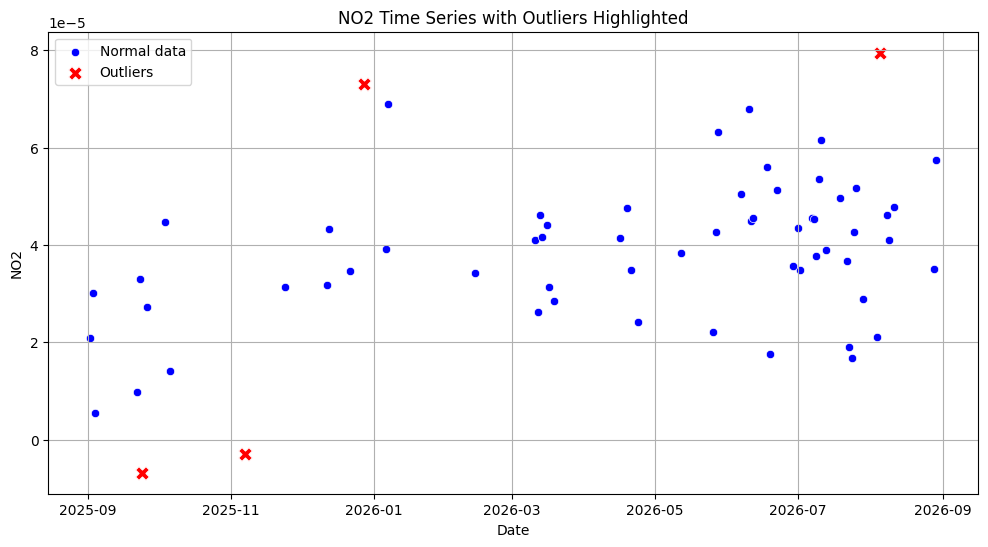

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

df_no2 = pd.read_csv("NO2_Timeseries.csv")
df_clean_no2 = df_no2.dropna(subset=['NO2']).copy()

model_no2 = IsolationForest(contamination=0.05, random_state=42)
pred_no2 = model_no2.fit_predict(df_clean_no2[['NO2']])

jumlah_outlier_no2 = (pred_no2 == -1).sum()
print(f"Jumlah outlier untuk NO2: {jumlah_outlier_no2}")

df_clean_no2['date'] = pd.to_datetime(df_clean_no2['date'])
df_outliers_no2 = df_clean_no2[pred_no2 == -1].copy()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='date', y='NO2', data=df_clean_no2, label='Normal data', color='blue')
sns.scatterplot(x='date', y='NO2', data=df_outliers_no2, label='Outliers', color='red', marker='X', s=100)
plt.title('NO2 Time Series with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('NO2')
plt.legend()
plt.grid(True)
plt.show()

### Outlier Analysis for SO2

Jumlah outlier untuk SO2: 7


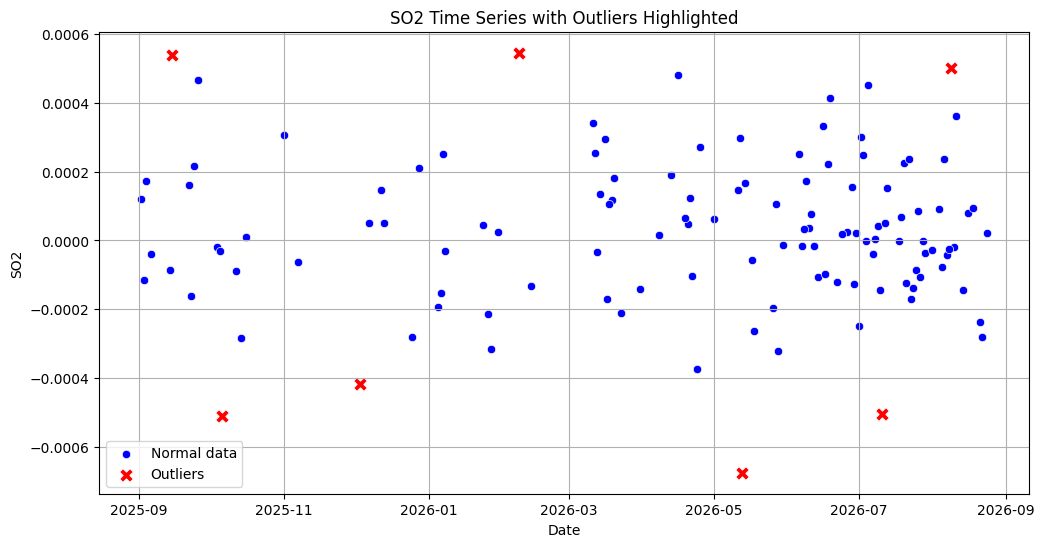

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

df_so2 = pd.read_csv("SO2_Timeseries.csv")
df_clean_so2 = df_so2.dropna(subset=['SO2']).copy()

model_so2 = IsolationForest(contamination=0.05, random_state=42)
pred_so2 = model_so2.fit_predict(df_clean_so2[['SO2']])

jumlah_outlier_so2 = (pred_so2 == -1).sum()
print(f"Jumlah outlier untuk SO2: {jumlah_outlier_so2}")

df_clean_so2['date'] = pd.to_datetime(df_clean_so2['date'])
df_outliers_so2 = df_clean_so2[pred_so2 == -1].copy()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='date', y='SO2', data=df_clean_so2, label='Normal data', color='blue')
sns.scatterplot(x='date', y='SO2', data=df_outliers_so2, label='Outliers', color='red', marker='X', s=100)
plt.title('SO2 Time Series with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('SO2')
plt.legend()
plt.grid(True)
plt.show()

### Outlier Analysis for O3

Jumlah outlier untuk O3: 18


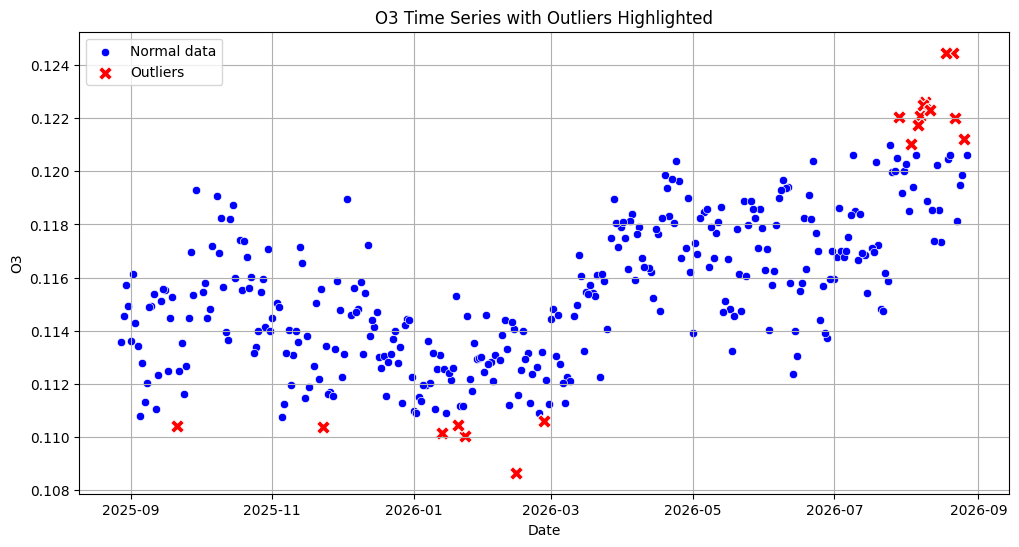

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

df_o3 = pd.read_csv("O3_Timeseries.csv")
df_clean_o3 = df_o3.dropna(subset=['O3']).copy()

model_o3 = IsolationForest(contamination=0.05, random_state=42)
pred_o3 = model_o3.fit_predict(df_clean_o3[['O3']])

jumlah_outlier_o3 = (pred_o3 == -1).sum()
print(f"Jumlah outlier untuk O3: {jumlah_outlier_o3}")

df_clean_o3['date'] = pd.to_datetime(df_clean_o3['date'])
df_outliers_o3 = df_clean_o3[pred_o3 == -1].copy()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='date', y='O3', data=df_clean_o3, label='Normal data', color='blue')
sns.scatterplot(x='date', y='O3', data=df_outliers_o3, label='Outliers', color='red', marker='X', s=100)
plt.title('O3 Time Series with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('O3')
plt.legend()
plt.grid(True)
plt.show()

### Outlier Analysis for CO

Jumlah outlier untuk CO: 9


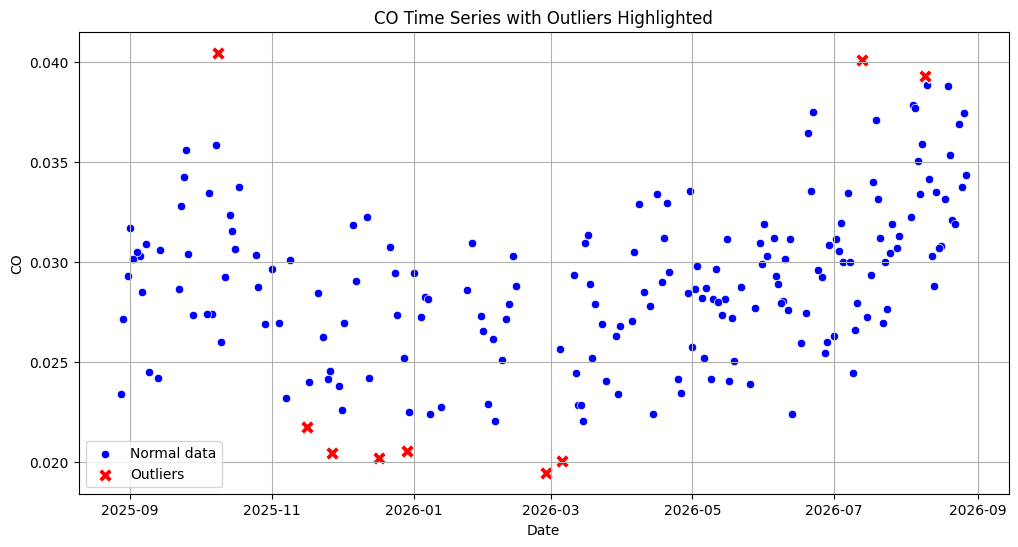

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

df_co = pd.read_csv("CO_Timeseries.csv")
df_clean_co = df_co.dropna(subset=['CO']).copy()

model_co = IsolationForest(contamination=0.05, random_state=42)
pred_co = model_co.fit_predict(df_clean_co[['CO']])

jumlah_outlier_co = (pred_co == -1).sum()
print(f"Jumlah outlier untuk CO: {jumlah_outlier_co}")

df_clean_co['date'] = pd.to_datetime(df_clean_co['date'])
df_outliers_co = df_clean_co[pred_co == -1].copy()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='date', y='CO', data=df_clean_co, label='Normal data', color='blue')
sns.scatterplot(x='date', y='CO', data=df_outliers_co, label='Outliers', color='red', marker='X', s=100)
plt.title('CO Time Series with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('CO')
plt.legend()
plt.grid(True)
plt.show()

Menggabungkan File CSV

In [39]:
import pandas as pd

df_o3 = pd.read_csv("NO2_Timeseries.csv")
df_co = pd.read_csv("SO2_Timeseries.csv")
df_no2 = pd.read_csv("O3_Timeseries.csv")
df_so2 = pd.read_csv("CO_Timeseries.csv")

dataframe_merged = pd.DataFrame({
    "date": df_o3['date'],
    "NO2": df_o3['NO2'],
    "SO2": df_co['SO2'],
    "O3": df_no2['O3'],
    "CO": df_so2['CO']
})

dataframe_merged.to_csv("Data_Polutan_Kota-Sukabumi.csv", index=False)

In [40]:
df = pd.read_csv("Data_Polutan_Kota-Sukabumi.csv")
df.head(10)

,date,NO2,SO2,O3,CO
0,2026-01-23,NaN,NaN,0.112012,NaN
1,2026-01-25,NaN,-0.000089,0.114920,NaN
2,2026-01-19,NaN,-0.000282,0.111034,NaN
3,2026-01-21,NaN,NaN,0.115395,NaN
4,2026-01-22,NaN,NaN,0.112775,0.030594
5,2026-01-26,NaN,NaN,0.111314,NaN
6,2026-01-20,NaN,NaN,0.114883,0.024208
7,2026-01-24,NaN,NaN,0.110778,NaN
8,2026-05-02,NaN,NaN,NaN,0.033745
9,2026-04-26,NaN,NaN,NaN,NaN


Deteksi dan Visualisasi Outlier (Metode IQR)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 4
          date       NO2
25  2025-09-24 -0.000007
69  2025-11-07 -0.000003
120 2025-12-28  0.000073
340 2026-08-05  0.000080


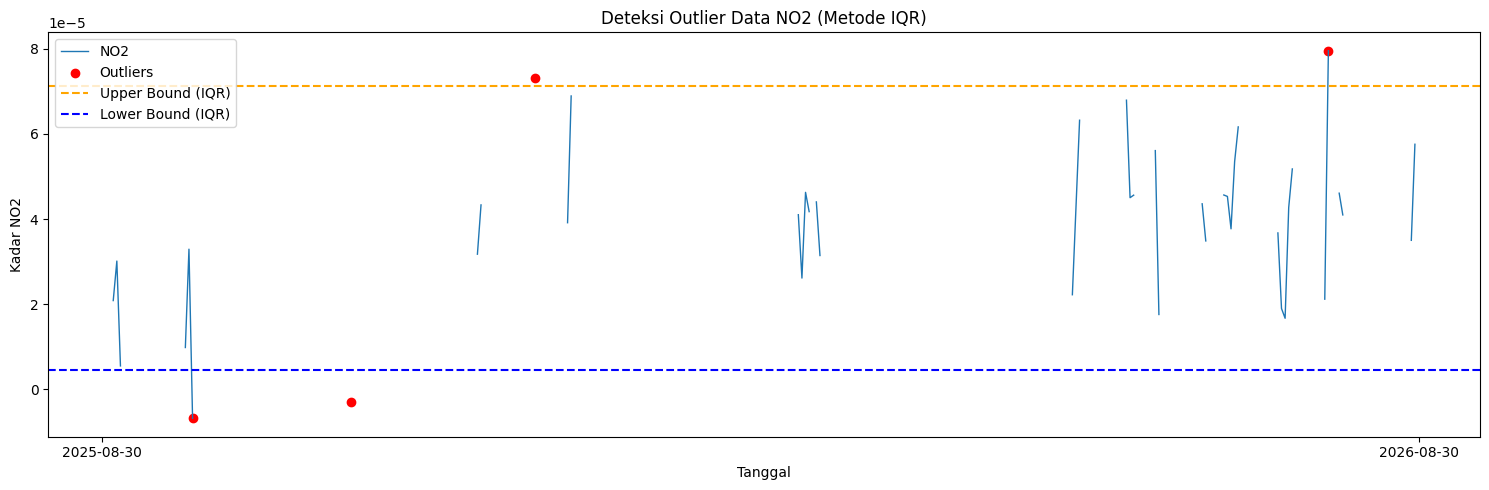

In [42]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data

In [52]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask(
    (df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)
)

# Lakukan interpolasi linier pada NaN yang sudah dibuat
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

# Gunting (clip) nilai-nilai hasil interpolasi agar berada dalam batas IQR awal
df['NO2_filled'] = df['NO2_filled'].clip(lower=lower_bound, upper=upper_bound)

# Simpan data yang telah dibersihkan dan diinterpolasi ke file CSV baru
df_no2_warudoyong = pd.DataFrame({
    "date": df['date'],
    "NO2": df['NO2_filled']
})
df_no2_warudoyong.to_csv("NO2_Warudoyong_filled.csv", index=False)

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Menggunakan batas bawah dan atas yang dihitung dari data asli (sebelum interpolasi)
# Nilai-nilai ini diambil dari hasil eksekusi sel EOzD5RDTPA9k sebelumnya.
lower_bound = 8.223020942097288e-06  # lower_bound dari NO2_Timeseries.csv
upper_bound = 6.312939019522183e-05  # upper_bound dari NO2_Timeseries.csv

# Filter outlier menggunakan batas yang sama
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR) berdasarkan batas awal:", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR) berdasarkan batas awal: 0
Empty DataFrame
Columns: [date, NO2]
Index: []


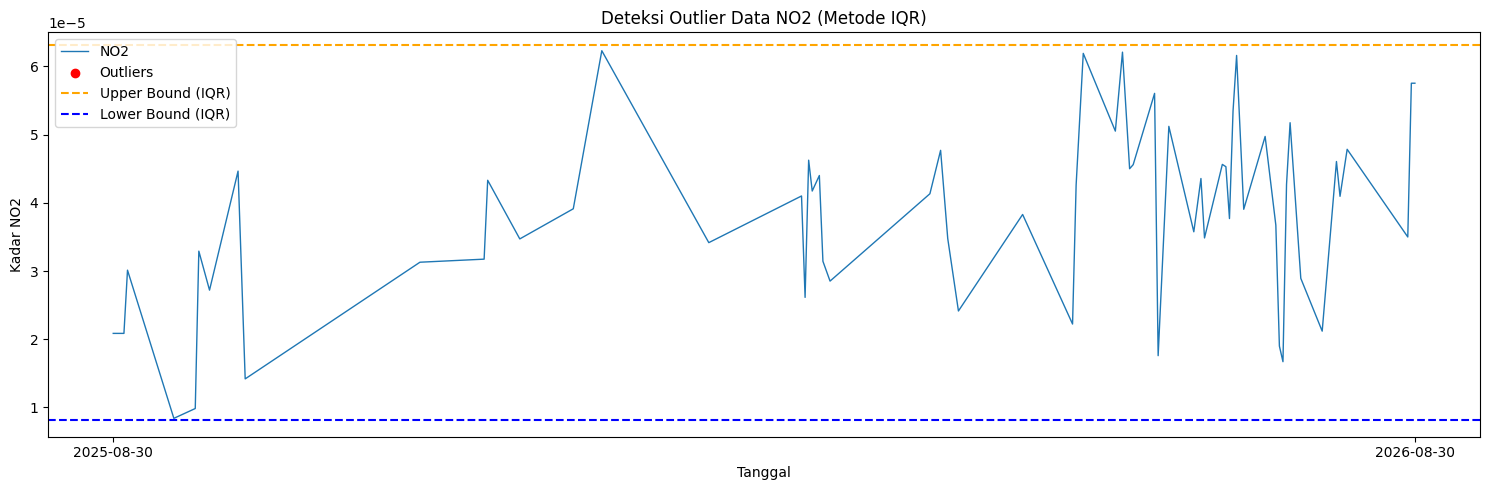

In [54]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Ekstraksi Fitur Deret Waktu (Time Series)

In [56]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.4 MB/s eta 0:00:00


In [57]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('NO2_Warudoyong_filled.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# Pastikan data di-casting ke tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

# Interpolasi terakhir untuk berjaga-jaga apabila terdapat sisa format nan
df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Inisiasi 68 Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------

# Fungsi bantuan (helper) merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Fungsi map pemanggilan fungsi TSFEL
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke file CSV
extracted_features_final.to_csv(f'{target_pollutant}_Warudoyong_TSFEL.csv', index=False)

Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang diekstrak pada NO2: 68


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


In [58]:
df = pd.read_csv("NO2_Warudoyong_TSFEL.csv")
df.head(10)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,5.120863e-07,0.013004,15.0,1.402976e-09,210.619392,0.000062,0.000036,0.000036,0.000008,0.000011,...,0.123104,0.441446,1.280249e-10,0.000781,0.000002,0.000017,2.042406,0.000017,3.400353e-10,0.0
